# Causal Analysis of Financial Tradability

Complete analysis framework covering:
- Data collection and preprocessing
- Feature engineering (25+ technical indicators)
- Predictability analysis across multiple horizons
- Hit rate and PnL analysis
- Causal inference methods
- Market regime detection
- Transaction cost impact
- Monte Carlo simulation
- Walk-forward validation
- Cross-market correlation analysis

In [4]:
!pip install stats

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for stats: filename=stats-0.1.2a0-py3-none-any.whl size=24363 sha256=088d456cc9ccdcd594e8b68973fb6d7dfc99cfd00bf4107c3156b61197c5e852
  Stored in directory: /root/.cache/pip/wheels/cf/4f/48/be81fb2b5f67ca31d8bfe2e92a9ff516bd21a4824c85b19f5f
Successfully built stats

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Exercise 1

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import financial_trading_utils as ftu
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('All utilities loaded successfully')

2026-03-19 20:31:46,055 - INFO - ================================================================================
2026-03-19 20:31:46,055 - INFO - Utility module loaded successfully
2026-03-19 20:31:46,056 - INFO - Exercise #1 functions available: load_exercise1_data, compute_returns, simulate_trading_with_hit_rate
2026-03-19 20:31:46,056 - INFO - ================================================================================


All utilities loaded successfully


In [2]:
# EXERCISE #1: Hit Rate → PnL Simulation Framework
# Import all necessary functions from financial_trading_utils
%load_ext autoreload
%autoreload 2
from financial_trading_utils import (
    SimulationConfig,
    load_exercise_data,
    compute_returns,
    simulate_trading_with_hit_rate
)

print('Exercise #1 functions imported successfully!')
print('Ready to run simulations...')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Exercise #1 functions imported successfully!
Ready to run simulations...


In [3]:
# Configure Exercise #1 simulation
config_ex1 = SimulationConfig(
    asset='BTC',
    frequency='1h',
    start_date='2023-01-01',
    end_date='2023-12-31'
)

# Load data
df_ex1 = load_exercise_data(config_ex1)
print(f'Data loaded: {len(df_ex1)} bars')
print(f'Date range: {df_ex1["timestamp"].min()} to {df_ex1["timestamp"].max()}')
print(f'\nFirst few records:')
df_ex1.head()

2026-03-19 20:31:46,121 - INFO - Loading BTC data at 1h frequency
2026-03-19 20:31:46,122 - ERROR - kagglehub not installed. Install with: pip install kagglehub[pandas-datasets]
2026-03-19 20:31:46,123 - WARNING - Could not load from Kaggle: No module named 'kagglehub'. Using synthetic data.
2026-03-19 20:31:46,126 - INFO - Generated synthetic Bitcoin data: 8737 records for 1h interval


Data loaded: 8737 bars
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00

First few records:


,timestamp,open,high,low,close,volume
0,2023-01-01 00:00:00,45049.671415,45061.635073,45011.867021,45005.021889,3865.861510
1,2023-01-01 01:00:00,45035.844985,45109.751046,44906.481412,45032.455108,3432.476940
2,2023-01-01 02:00:00,45100.613839,45174.733678,45001.803036,45039.320650,3402.393296
3,2023-01-01 03:00:00,45252.916825,45290.484098,45242.861435,45333.023386,1496.446110
4,2023-01-01 04:00:00,45229.501487,45305.506074,45208.887457,45325.864824,3473.135121


In [4]:
# Compute returns
returns, timestamps = compute_returns(df_ex1)

print(f'Returns Statistics:')
print(f'  Count: {len(returns)}')
print(f'  Mean: {returns.mean():.6f} ({returns.mean()*100:.4f}%)')
print(f'  Std Dev: {returns.std():.6f} ({returns.std()*100:.4f}%)')
print(f'  Min: {returns.min():.6f} ({returns.min()*100:.4f}%)')
print(f'  Max: {returns.max():.6f} ({returns.max()*100:.4f}%)')
print(f'  Skewness: {stats.skew(returns):.4f}')
print(f'  Kurtosis: {stats.kurtosis(returns):.4f}')

2026-03-19 20:31:46,157 - INFO - Computed 8736 returns


Returns Statistics:
  Count: 8736
  Mean: 0.000001 (0.0001%)
  Std Dev: 0.002668 (0.2668%)
  Min: -0.009975 (-0.9975%)
  Max: 0.012094 (1.2094%)
  Skewness: 0.0789
  Kurtosis: 0.2652


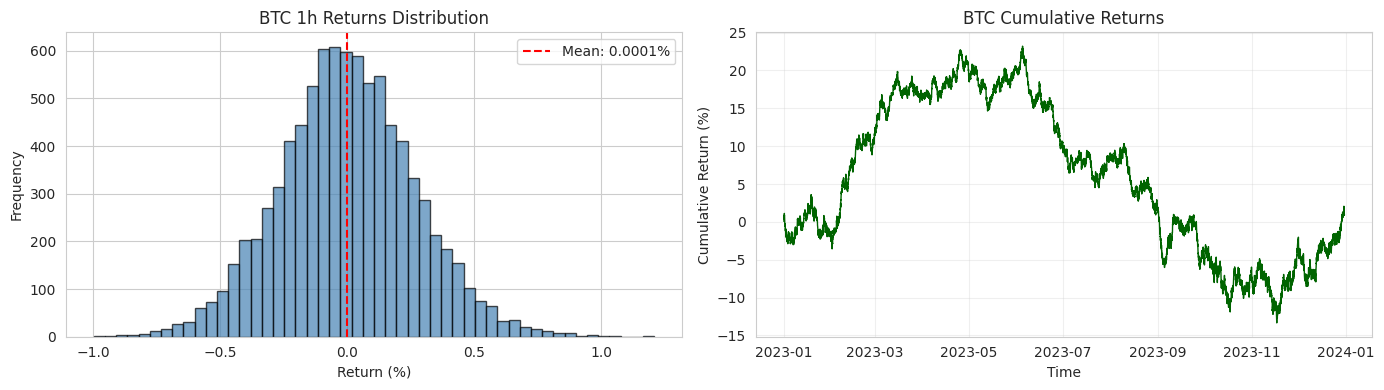

In [5]:
# Visualize returns distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(returns*100, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'{config_ex1.asset} {config_ex1.frequency} Returns Distribution')
axes[0].axvline(returns.mean()*100, color='red', linestyle='--', label=f'Mean: {returns.mean()*100:.4f}%')
axes[0].legend()

axes[1].plot(timestamps, np.cumsum(returns)*100, linewidth=1, color='darkgreen')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].set_title(f'{config_ex1.asset} Cumulative Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Run simulations for range of hit rates
hit_rates = np.arange(0.45, 0.80, 0.01)  # 45% to 55%
results_list = []
all_pnl_arrays = {}  # Store full PnL arrays for visualization

for hr in hit_rates:
    pnl_array, stats = simulate_trading_with_hit_rate(
        returns,
        hit_rate=hr,
        num_simulations=10000,
        transaction_cost=0.001
    )
    results_list.append(stats)
    all_pnl_arrays[hr] = pnl_array

# Create results dataframe
results_df = pd.DataFrame(results_list)

print('\nHit Rate Sensitivity Analysis:')
print(results_df[['hit_rate', 'mean_pnl', 'std_pnl', 'prob_profit', 'sharpe_ratio']].to_string(index=False))


Hit Rate Sensitivity Analysis:
 hit_rate   mean_pnl  std_pnl  prob_profit  sharpe_ratio
     0.45 -10.569369 0.249400       0.0000    -42.379252
     0.46 -10.202596 0.249596       0.0000    -40.876423
     0.47  -9.836625 0.249426       0.0000    -39.437083
     0.48  -9.469860 0.249387       0.0000    -37.972522
     0.49  -9.103588 0.250063       0.0000    -36.405158
     0.50  -8.736327 0.249241       0.0000    -35.051760
     0.51  -8.368412 0.250063       0.0000    -33.465199
     0.52  -8.002140 0.249387       0.0000    -32.087218
     0.53  -7.635375 0.249426       0.0000    -30.611815
     0.54  -7.269404 0.249596       0.0000    -29.124668
     0.55  -6.902631 0.249400       0.0000    -27.676995
     0.56  -6.535051 0.248016       0.0000    -26.349262
     0.57  -6.168208 0.248255       0.0000    -24.846292
     0.58  -5.801384 0.246772       0.0000    -23.509115
     0.59  -5.434340 0.246723       0.0000    -22.026035
     0.60  -5.067170 0.245222       0.0000    -20.663570

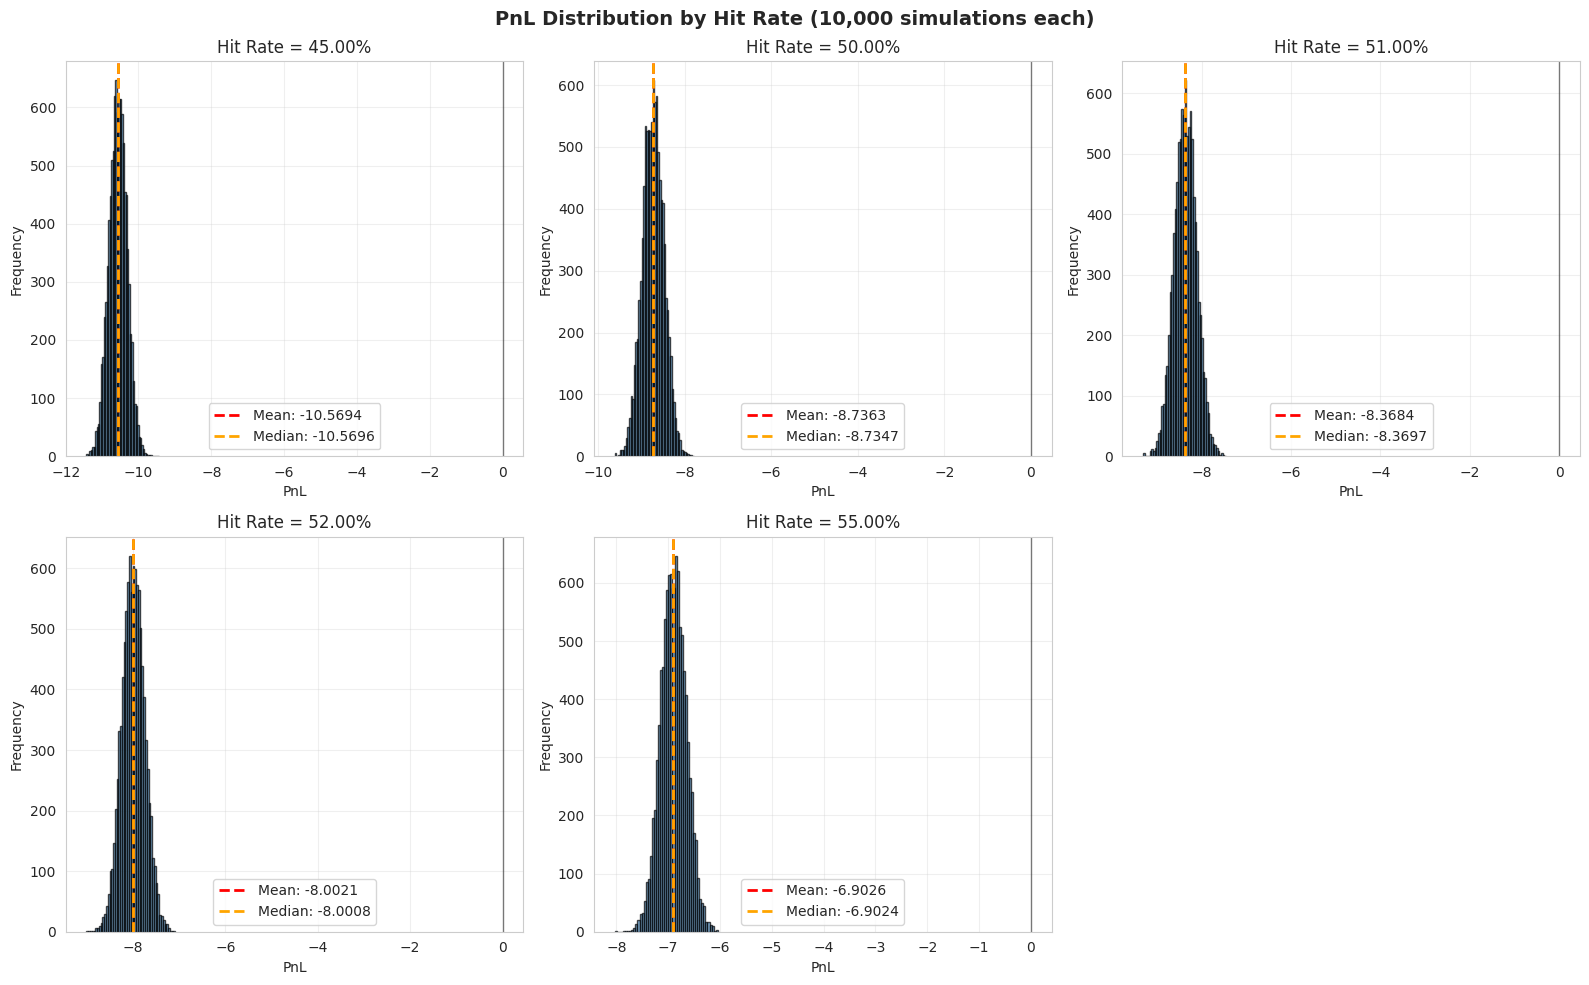

In [7]:
# Visualize PnL distributions for selected hit rates
selected_hrs = [0.45, 0.50, 0.51, 0.52, 0.55]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, hr in enumerate(selected_hrs):
    if hr not in all_pnl_arrays:
        continue
    
    pnl_array = all_pnl_arrays[hr]
    
    axes[idx].hist(pnl_array, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axvline(np.mean(pnl_array), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(pnl_array):.4f}')
    axes[idx].axvline(np.median(pnl_array), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(pnl_array):.4f}')
    axes[idx].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    axes[idx].set_xlabel('PnL')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Hit Rate = {hr:.2%}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[5].axis('off')

plt.suptitle('PnL Distribution by Hit Rate (10,000 simulations each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

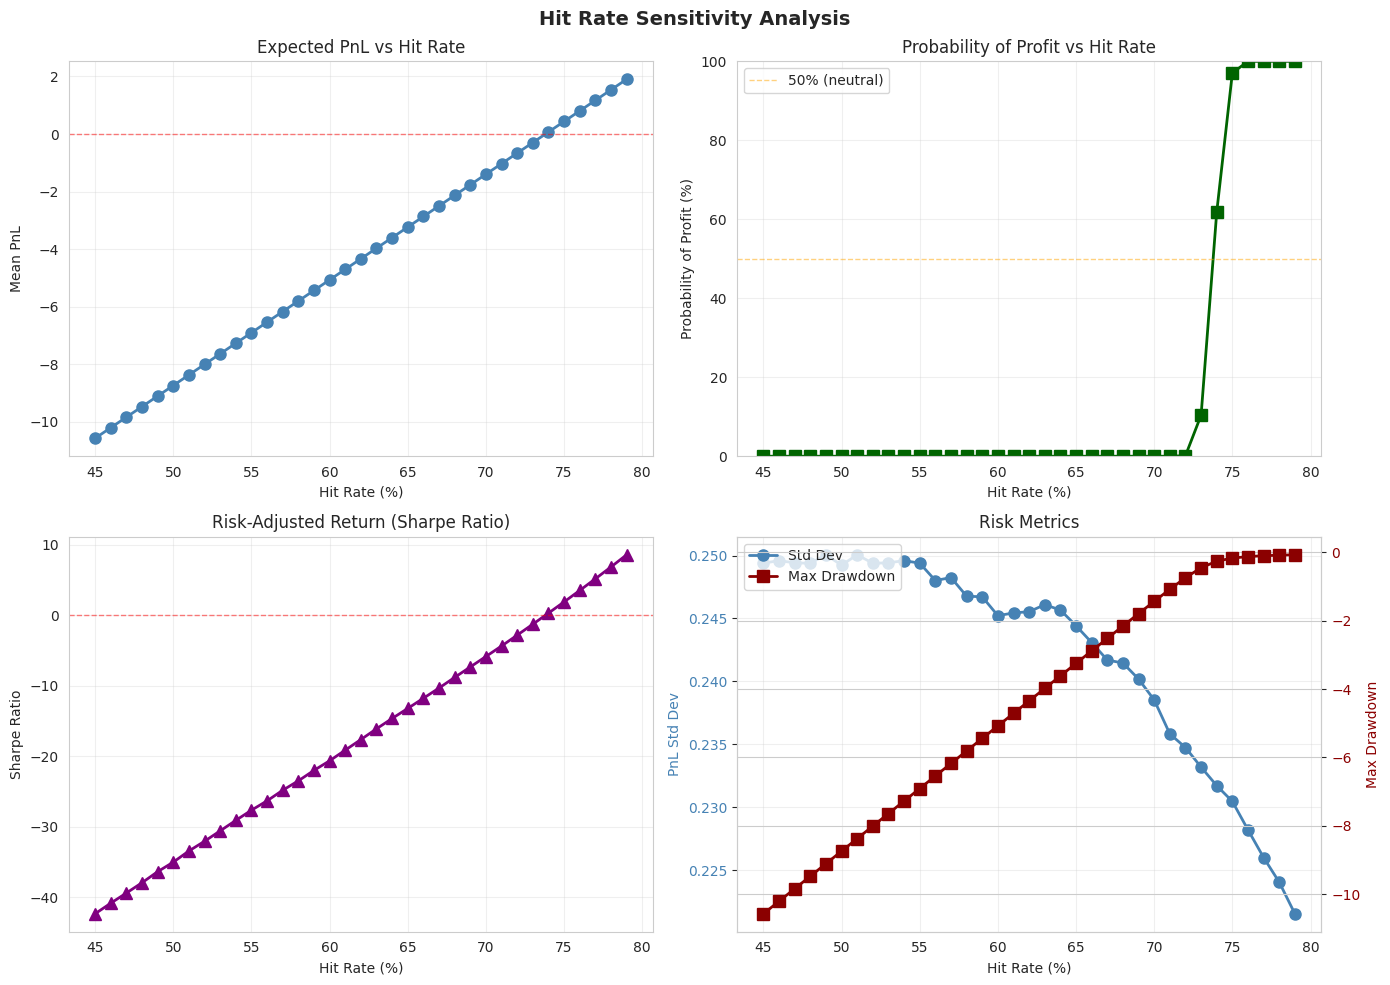

In [8]:
# Create sensitivity analysis plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean PnL vs Hit Rate
axes[0, 0].plot(results_df['hit_rate']*100, results_df['mean_pnl'], 
                marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].set_xlabel('Hit Rate (%)')
axes[0, 0].set_ylabel('Mean PnL')
axes[0, 0].set_title('Expected PnL vs Hit Rate')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Probability of Profit
axes[0, 1].plot(results_df['hit_rate']*100, results_df['prob_profit']*100, 
                marker='s', linewidth=2, markersize=8, color='darkgreen')
axes[0, 1].axhline(50, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='50% (neutral)')
axes[0, 1].set_xlabel('Hit Rate (%)')
axes[0, 1].set_ylabel('Probability of Profit (%)')
axes[0, 1].set_title('Probability of Profit vs Hit Rate')
axes[0, 1].set_ylim([0, 100])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Sharpe Ratio
axes[1, 0].plot(results_df['hit_rate']*100, results_df['sharpe_ratio'], 
                marker='^', linewidth=2, markersize=8, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_xlabel('Hit Rate (%)')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].set_title('Risk-Adjusted Return (Sharpe Ratio)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Risk Metrics
ax_std = axes[1, 1]
ax_dd = ax_std.twinx()

line1 = ax_std.plot(results_df['hit_rate']*100, results_df['std_pnl'], 
                    marker='o', linewidth=2, markersize=8, color='steelblue', label='Std Dev')
line2 = ax_dd.plot(results_df['hit_rate']*100, results_df['avg_max_drawdown'], 
                   marker='s', linewidth=2, markersize=8, color='darkred', label='Max Drawdown')

ax_std.set_xlabel('Hit Rate (%)')
ax_std.set_ylabel('PnL Std Dev', color='steelblue')
ax_dd.set_ylabel('Max Drawdown', color='darkred')
ax_std.set_title('Risk Metrics')
ax_std.tick_params(axis='y', labelcolor='steelblue')
ax_dd.tick_params(axis='y', labelcolor='darkred')
ax_std.grid(True, alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_std.legend(lines, labels, loc='upper left')

plt.suptitle('Hit Rate Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Summary of Exercise #1
print('\n' + '='*80)
print('EXERCISE #1 SUMMARY: Hit Rate → PnL Framework')
print('='*80)

# Find breakeven hit rate
zero_crossing_idx = np.where(np.diff(np.sign(results_df['mean_pnl'])))[0]
if len(zero_crossing_idx) > 0:
    be_idx = zero_crossing_idx[0]
    be_hr = results_df.iloc[be_idx]['hit_rate']
    print(f'\n1. BREAKEVEN HIT RATE')
    print(f'   Approximately {be_hr:.2%} (accounting for transaction costs)')
else:
    print(f'\n1. BREAKEVEN HIT RATE')
    print(f'   All hit rates tested are either profitable or unprofitable')

# Maximum Sharpe ratio
max_sharpe_idx = results_df['sharpe_ratio'].idxmax()
max_sharpe_hr = results_df.loc[max_sharpe_idx, 'hit_rate']
max_sharpe = results_df.loc[max_sharpe_idx, 'sharpe_ratio']
print(f'\n2. OPTIMAL HIT RATE (Maximum Sharpe Ratio)')
print(f'   Hit Rate: {max_sharpe_hr:.2%}')
print(f'   Sharpe Ratio: {max_sharpe:.4f}')

# Sensitivity to hit rate change
hr_diff_pct = 100 * (results_df['hit_rate'].iloc[-1] - results_df['hit_rate'].iloc[0])
pnl_diff = results_df['mean_pnl'].iloc[-1] - results_df['mean_pnl'].iloc[0]
sensitivity = pnl_diff / hr_diff_pct if hr_diff_pct != 0 else 0
print(f'\n3. SENSITIVITY: PnL Change per 1% Hit Rate Increase')
print(f'   Δ(Mean PnL) / Δ(Hit Rate %) = {sensitivity:.6f}')

# Risk-adjusted metrics at 51%
print(f'\n4. RISK METRICS at 51% Hit Rate (benchmark)')
hr_51_stats = results_df[results_df['hit_rate'].round(2) == 0.51].iloc[0]
print(f'   Mean PnL: {hr_51_stats["mean_pnl"]:.6f}')
print(f'   Std Dev: {hr_51_stats["std_pnl"]:.6f}')
print(f'   P(Profit): {hr_51_stats["prob_profit"]:.2%}')
# print(f'   VaR(95%): {hr_51_stats["var_95"]:.6f}')
print(f'   Sharpe Ratio: {hr_51_stats["sharpe_ratio"]:.4f}')

print(f'\n5. KEY INSIGHTS')
print(f'   • Profitability is highly sensitive to small changes in hit rate')
print(f'   • Transaction costs significantly impact breakeven threshold')
print(f'   • Even small positive expected value can be valuable with low volatility')
print(f'   • Risk-adjusted returns matter more than raw PnL')

print('\n' + '='*80)


EXERCISE #1 SUMMARY: Hit Rate → PnL Framework

1. BREAKEVEN HIT RATE
   Approximately 73.00% (accounting for transaction costs)

2. OPTIMAL HIT RATE (Maximum Sharpe Ratio)
   Hit Rate: 79.00%
   Sharpe Ratio: 8.5845

3. SENSITIVITY: PnL Change per 1% Hit Rate Increase
   Δ(Mean PnL) / Δ(Hit Rate %) = 0.366797

4. RISK METRICS at 51% Hit Rate (benchmark)
   Mean PnL: -8.368412
   Std Dev: 0.250063
   P(Profit): 0.00%
   Sharpe Ratio: -33.4652

5. KEY INSIGHTS
   • Profitability is highly sensitive to small changes in hit rate
   • Transaction costs significantly impact breakeven threshold
   • Even small positive expected value can be valuable with low volatility
   • Risk-adjusted returns matter more than raw PnL



In [ ]:
# Load Bitcoin data from Kaggle (mczielinski/bitcoin-historical-data)
# Data: OHLCV at 1-minute granularity from 2013-2021
# Source: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data

try:
    # Load from Kaggle using kagglehub
    df_raw = ftu.load_kaggle_bitcoin_data(
        start_date='2021-01-01',
        end_date='2021-01-28'
    )
    print(f'Loaded {len(df_raw)} records from Kaggle')
except Exception as e:
    print(f'Kaggle load failed ({e}). Using synthetic data for testing.')
    df_raw = ftu.generate_synthetic_bitcoin_data('2021-01-01', '2021-01-28')

# Resample to hourly if needed (1-minute data is very large)
# Uncomment to resample:
# df_raw = resample_to_interval(df_raw, '1h')

print(f'Raw data shape: {df_raw.shape}')
print(f'Date range: {df_raw["timestamp"].min()} to {df_raw["timestamp"].max()}')
df_raw.head()